# 🛠️ Faz 6: Feature Engineering

**Hedef:** Müşteri seviyesinde feature tablosu (Gold) oluşturmak.

## Problem

**Customer Lifetime Value (CLV) Tahmini** — Regresyon problemi.

Müşterinin **geçmiş 18 aylık davranışından** yola çıkarak **sonraki 6 ayda yapacağı harcamayı** tahmin edeceğiz.

## Zaman Bölümlemesi

## Üretilecek Feature'lar (10 adet)

| # | Feature | Açıklama | İş Mantığı |
|---|---------|----------|------------|
| 1 | `recency_days` | Son alışverişten gözlem tarihine gün | Yakın alışveriş = sadık müşteri |
| 2 | `frequency` | Toplam fatura sayısı | Sık alışveriş = aktif müşteri |
| 3 | `monetary` | Toplam harcama (£) | Yüksek harcama = değerli müşteri |
| 4 | `avg_basket_value` | Ortalama sepet tutarı | Pahalı sepet alışkanlığı |
| 5 | `avg_days_between_purchases` | Alışverişler arası gün | Düzenlilik göstergesi |
| 6 | `unique_products` | Kaç farklı ürün aldı | Ürün çeşitliliği |
| 7 | `cancellation_count` | Geçmişteki iptal sayısı | Memnuniyetsizlik sinyali |
| 8 | `active_months` | Kaç farklı ayda alışveriş yapmış | Müşteri aktiflik süresi |
| 9 | `most_active_hour` | En çok hangi saatte alışveriş yapıyor | Davranış paterni |
| 10 | `country` | Müşterinin ülkesi (kategorik) | Coğrafi sinyal |

## Target (Y)

`future_spending` — Tahmin döneminde toplam harcama (£). Regresyon hedefi.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

from src.spark_session import get_spark_session

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

spark = get_spark_session(
    app_name="FeatureEngineering",
    master="local[2]",
    driver_memory="3g"
)

print(f"✅ Spark {spark.version}")

26/05/11 09:33:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


✅ Spark 3.5.1


In [2]:
SILVER_PURCHASES = os.path.abspath("../delta_lake/silver/transactions")
SILVER_CANCELLATIONS = os.path.abspath("../delta_lake/silver/cancellations")

df_purchases = spark.read.format("delta").load(SILVER_PURCHASES)
df_cancellations = spark.read.format("delta").load(SILVER_CANCELLATIONS)

print(f"🛒 Purchases:    {df_purchases.count():,} satır")
print(f"❌ Cancellations: {df_cancellations.count():,} satır")

# Sadece gerekli sütunları seç (performans için)
df_purchases.select("kullanici_ID", "invoice_date", "total_price", "ilgili_ID", 
                    "stock_code", "country", "quantity", "unit_price").show(5)

26/05/11 09:33:33 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


🛒 Purchases:    6,932 satır
❌ Cancellations: 170 satır
+------------+-------------------+-----------+---------+----------+--------------+--------+----------+
|kullanici_ID|       invoice_date|total_price|ilgili_ID|stock_code|       country|quantity|unit_price|
+------------+-------------------+-----------+---------+----------+--------------+--------+----------+
|       12362|2009-12-01 10:10:00|      130.0|   489447|      POST|       Belgium|       1|     130.0|
|       12577|2009-12-03 19:31:00|       3.95|   490139|     22114|        France|       1|      3.95|
|       12577|2009-12-03 19:31:00|       5.95|   490139|     22125|        France|       1|      5.95|
|       12636|2009-12-01 09:55:00|      141.0|   489444|      POST|           USA|       1|     141.0|
|       12835|2009-12-03 12:13:00|        2.1|   490009|     21157|United Kingdom|       1|       2.1|
+------------+-------------------+-----------+---------+----------+--------------+--------+----------+
only showing top 5

## 1. Zamansal Bölümleme

Veriyi **feature dönemi** ve **target dönemi** olarak ikiye böleceğiz.

Bu **kritik bir adım** çünkü ML modelimiz "geçmişten geleceği tahmin etmeli" — eğitim sırasında ve gerçek hayatta da öyle. Eğer feature'ları aynı dönemden türetip target'ı da aynı dönemden alırsak, "geleceği bilen feature" yapmış oluruz (data leakage). Bu yüzden zaman bölümlemesi ML'in temel disiplinlerinden biri.

In [3]:
from pyspark.sql.functions import min as _min, max as _max

date_range = df_purchases.agg(
    _min("invoice_date").alias("min_date"),
    _max("invoice_date").alias("max_date")
).collect()[0]

min_date = date_range['min_date']
max_date = date_range['max_date']

print(f"📅 En eski işlem: {min_date}")
print(f"📅 En yeni işlem: {max_date}")
print(f"⏱️  Toplam aralık: {(max_date - min_date).days} gün")

📅 En eski işlem: 2009-12-01 07:45:00
📅 En yeni işlem: 2009-12-04 09:31:00
⏱️  Toplam aralık: 3 gün


In [4]:
from datetime import timedelta

# Veriyi 75% geçmiş + 25% gelecek olarak böl
total_days = (max_date - min_date).days
split_date = min_date + timedelta(days=int(total_days * 0.75))

print(f"📊 Bölümleme stratejisi:")
print(f"   FEATURE DÖNEMİ: {min_date.date()} → {split_date.date()}")
print(f"                    ({(split_date - min_date).days} gün, ~%75)")
print(f"   TARGET DÖNEMİ:   {split_date.date()} → {max_date.date()}")
print(f"                    ({(max_date - split_date).days} gün, ~%25)")

📊 Bölümleme stratejisi:
   FEATURE DÖNEMİ: 2009-12-01 → 2009-12-03
                    (2 gün, ~%75)
   TARGET DÖNEMİ:   2009-12-03 → 2009-12-04
                    (1 gün, ~%25)


In [5]:
from pyspark.sql.functions import col, lit, to_timestamp

split_date_str = split_date.strftime("%Y-%m-%d %H:%M:%S")

# Feature dönemi (geçmiş)
df_feature_period = df_purchases.filter(col("invoice_date") < lit(split_date_str))

# Target dönemi (gelecek) — sadece purchase, cancellation'ı target'a katmıyoruz
df_target_period = df_purchases.filter(col("invoice_date") >= lit(split_date_str))

# Cancellation'ları da bölelim — feature olarak kullanacağız
df_canc_feature = df_cancellations.filter(col("invoice_date") < lit(split_date_str))

print(f"📊 Feature dönemi (purchase): {df_feature_period.count():,} satır")
print(f"📊 Target dönemi (purchase):  {df_target_period.count():,} satır")
print(f"📊 Feature dönemi (canc):     {df_canc_feature.count():,} satır")

📊 Feature dönemi (purchase): 4,432 satır
📊 Target dönemi (purchase):  2,500 satır
📊 Feature dönemi (canc):     125 satır


## 2. RFM Feature'ları (Recency, Frequency, Monetary)

E-ticaret ML projelerinin **çekirdek özellikleri**:

- **Recency:** Son alışverişten "şimdi"ye geçen gün sayısı (düşük = iyi)
- **Frequency:** Toplam alışveriş (fatura) sayısı (yüksek = iyi)
- **Monetary:** Toplam harcama miktarı (yüksek = iyi)

Bu üç değer birlikte müşteri segmentasyonunda **40+ yıldır** kullanılıyor. Bizim regresyon modelimiz için de güçlü sinyaller.

> **Gözlem tarihi:** Recency'yi hesaplamak için bir referans tarih gerek. Biz `split_date`'i (feature döneminin sonu) gözlem tarihi olarak kullanacağız.

In [6]:
from pyspark.sql.functions import datediff, countDistinct, sum as _sum, max as _max_col

# Gözlem tarihi: feature dönemi bitişi
observation_date = lit(split_date_str).cast("timestamp")

df_rfm = df_feature_period.groupBy("kullanici_ID").agg(
    # Recency: son işlemden gözlem tarihine kaç gün?
    datediff(observation_date, _max_col("invoice_date")).alias("recency_days"),
    
    # Frequency: kaç farklı fatura?
    countDistinct("ilgili_ID").alias("frequency"),
    
    # Monetary: toplam harcama
    _sum("total_price").alias("monetary")
)

print(f"📊 RFM tablo: {df_rfm.count():,} müşteri")
df_rfm.show(10)

# İstatistikler
print("\n📊 RFM İstatistikleri:")
df_rfm.describe().show()

📊 RFM tablo: 183 müşteri
+------------+------------+---------+------------------+
|kullanici_ID|recency_days|frequency|          monetary|
+------------+------------+---------+------------------+
|       14527|           1|        1| 923.7899999999998|
|       14654|           2|        1|246.85999999999999|
|       16011|           2|        1|181.50000000000003|
|       16797|           1|        1|176.87999999999997|
|       17056|           2|        1|128.60000000000002|
|       17238|           2|        1|             251.1|
|       14560|           1|        1|266.59999999999997|
|       15602|           1|        1|261.29999999999995|
|       16131|           1|        1|1317.9700000000003|
|       14739|           1|        1| 618.4300000000001|
+------------+------------+---------+------------------+
only showing top 10 rows


📊 RFM İstatistikleri:
+-------+------------------+------------------+------------------+------------------+
|summary|      kullanici_ID|      recency_

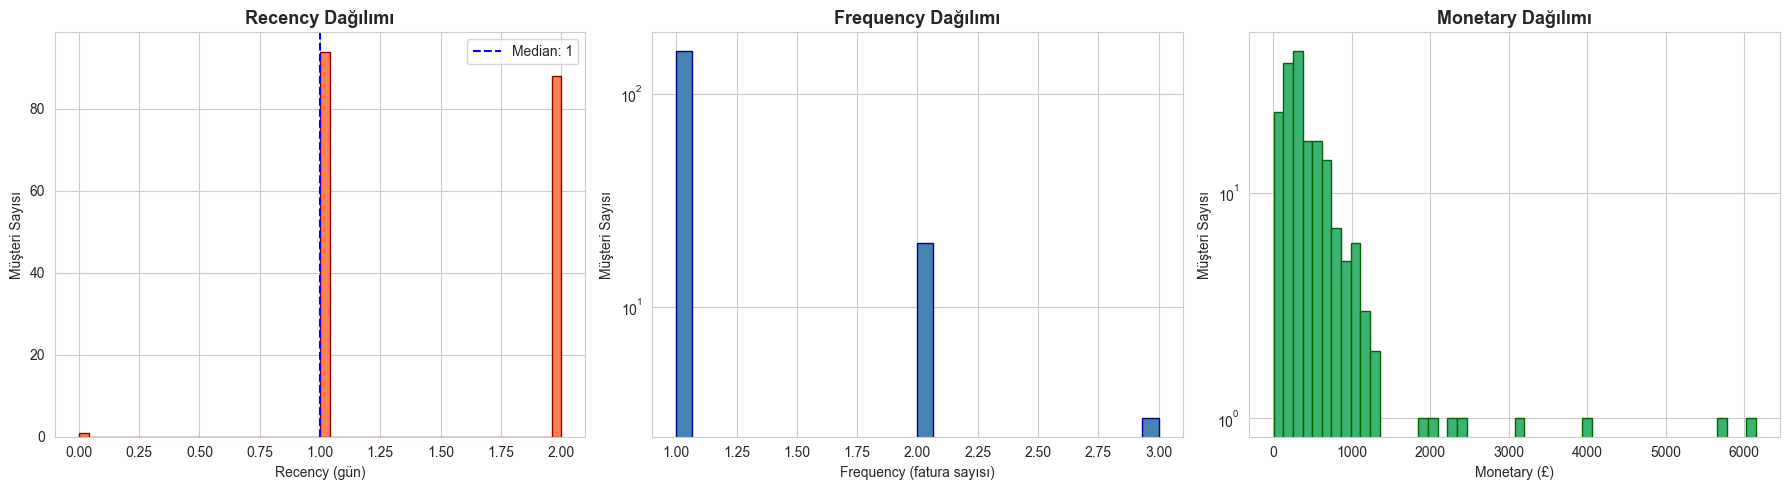

✅ RFM dağılım görseli kaydedildi


In [7]:
df_rfm_pd = df_rfm.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency
axes[0].hist(df_rfm_pd['recency_days'], bins=50, color='coral', edgecolor='darkred')
axes[0].set_xlabel('Recency (gün)')
axes[0].set_ylabel('Müşteri Sayısı')
axes[0].set_title('Recency Dağılımı', fontsize=13, fontweight='bold')
axes[0].axvline(df_rfm_pd['recency_days'].median(), color='blue', linestyle='--', label=f'Median: {df_rfm_pd["recency_days"].median():.0f}')
axes[0].legend()

# Frequency
axes[1].hist(df_rfm_pd['frequency'], bins=30, color='steelblue', edgecolor='darkblue')
axes[1].set_xlabel('Frequency (fatura sayısı)')
axes[1].set_ylabel('Müşteri Sayısı')
axes[1].set_title('Frequency Dağılımı', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')

# Monetary (log scale çünkü çok çarpık)
axes[2].hist(df_rfm_pd['monetary'], bins=50, color='mediumseagreen', edgecolor='darkgreen')
axes[2].set_xlabel('Monetary (£)')
axes[2].set_ylabel('Müşteri Sayısı')
axes[2].set_title('Monetary Dağılımı', fontsize=13, fontweight='bold')
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig('../docs/images/06_rfm_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ RFM dağılım görseli kaydedildi")

## 3. İleri Seviye Feature'lar

RFM'in ötesinde, müşteri davranışını daha derinlemesine yakalayan özellikler:

- `avg_basket_value` — Sepet başına ortalama harcama
- `avg_days_between_purchases` — Alışverişler arası ortalama gün
- `unique_products` — Müşterinin kaç farklı ürün satın aldığı
- `cancellation_count` — Geçmişte kaç iptal yaptığı
- `active_months` — Kaç farklı ayda aktif
- `most_active_hour` — En çok hangi saatte alışveriş yapıyor
- `country` — Müşterinin ülkesi

In [8]:
df_basket = df_feature_period.groupBy("kullanici_ID", "ilgili_ID").agg(
    _sum("total_price").alias("basket_total")
).groupBy("kullanici_ID").agg(
    (_sum("basket_total") / countDistinct("ilgili_ID")).alias("avg_basket_value")
)

print(f"📊 Avg Basket: {df_basket.count():,} müşteri")
df_basket.show(5)

📊 Avg Basket: 183 müşteri
+------------+------------------+
|kullanici_ID|  avg_basket_value|
+------------+------------------+
|       14527| 923.7899999999998|
|       14654|246.85999999999999|
|       16011|181.50000000000003|
|       16797|176.87999999999997|
|       17056|128.60000000000002|
+------------+------------------+
only showing top 5 rows



In [11]:
from pyspark.sql.functions import when
from pyspark.sql.functions import min as _min_col

df_purchase_span = df_feature_period.groupBy("kullanici_ID").agg(
    _min_col("invoice_date").alias("first_purchase"),
    _max_col("invoice_date").alias("last_purchase"),
    countDistinct("ilgili_ID").alias("invoice_count")
).withColumn(
    "purchase_span_days",
    datediff(col("last_purchase"), col("first_purchase"))
).withColumn(
    "avg_days_between_purchases",
    # Eğer tek fatura varsa 0, yoksa span / (count - 1)
    when(col("invoice_count") > 1, 
         col("purchase_span_days") / (col("invoice_count") - 1))
    .otherwise(lit(0.0))
).select("kullanici_ID", "avg_days_between_purchases")

print(f"📊 Avg Days Between: {df_purchase_span.count():,} müşteri")
df_purchase_span.show(5)

📊 Avg Days Between: 183 müşteri
+------------+--------------------------+
|kullanici_ID|avg_days_between_purchases|
+------------+--------------------------+
|       14527|                       0.0|
|       14654|                       0.0|
|       16011|                       0.0|
|       16797|                       0.0|
|       17056|                       0.0|
+------------+--------------------------+
only showing top 5 rows



In [12]:
df_unique_products = df_feature_period.groupBy("kullanici_ID").agg(
    countDistinct("stock_code").alias("unique_products")
)

print(f"📊 Unique Products: {df_unique_products.count():,} müşteri")
df_unique_products.show(5)

📊 Unique Products: 183 müşteri
+------------+---------------+
|kullanici_ID|unique_products|
+------------+---------------+
|       13564|             17|
|       14204|             54|
|       14527|             58|
|       14654|             27|
|       14669|             84|
+------------+---------------+
only showing top 5 rows



In [13]:
df_canc_count = df_canc_feature.groupBy("kullanici_ID").agg(
    countDistinct("ilgili_ID").alias("cancellation_count")
)

print(f"📊 Cancellation Count: {df_canc_count.count():,} müşteri (iptal yapmış olanlar)")
df_canc_count.show(5)

📊 Cancellation Count: 48 müşteri (iptal yapmış olanlar)
+------------+------------------+
|kullanici_ID|cancellation_count|
+------------+------------------+
|       16955|                 1|
|       13711|                 1|
|       14558|                 1|
|       15254|                 1|
|       15614|                 1|
+------------+------------------+
only showing top 5 rows



In [14]:
from pyspark.sql.functions import date_format

df_active_months = df_feature_period.withColumn(
    "year_month", date_format("invoice_date", "yyyy-MM")
).groupBy("kullanici_ID").agg(
    countDistinct("year_month").alias("active_months")
)

print(f"📊 Active Months: {df_active_months.count():,} müşteri")
df_active_months.show(5)

📊 Active Months: 183 müşteri
+------------+-------------+
|kullanici_ID|active_months|
+------------+-------------+
|       14061|            1|
|       14527|            1|
|       16887|            1|
|       18037|            1|
|       13819|            1|
+------------+-------------+
only showing top 5 rows



In [15]:
from pyspark.sql.functions import hour, count
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# Her müşteri için saat bazında count
df_hourly = df_feature_period.withColumn(
    "hour", hour("invoice_date")
).groupBy("kullanici_ID", "hour").agg(
    count("*").alias("hour_count")
)

# Her müşterinin en çok alışveriş yaptığı saati bul
window_spec = Window.partitionBy("kullanici_ID").orderBy(col("hour_count").desc())

df_most_hour = df_hourly.withColumn(
    "rank", row_number().over(window_spec)
).filter(col("rank") == 1).select(
    "kullanici_ID",
    col("hour").alias("most_active_hour")
)

print(f"📊 Most Active Hour: {df_most_hour.count():,} müşteri")
df_most_hour.show(5)

📊 Most Active Hour: 183 müşteri
+------------+----------------+
|kullanici_ID|most_active_hour|
+------------+----------------+
|       12362|              10|
|       12435|              13|
|       12437|              16|
|       12490|              12|
|       12533|              11|
+------------+----------------+
only showing top 5 rows



In [16]:
# Her müşterinin en çok kullandığı ülke (genelde 1 tane oluyor)
df_country = df_feature_period.groupBy("kullanici_ID", "country").agg(
    count("*").alias("country_count")
)

window_country = Window.partitionBy("kullanici_ID").orderBy(col("country_count").desc())

df_customer_country = df_country.withColumn(
    "rank", row_number().over(window_country)
).filter(col("rank") == 1).select("kullanici_ID", "country")

print(f"📊 Country: {df_customer_country.count():,} müşteri")
df_customer_country.show(5)

📊 Country: 183 müşteri
+------------+-------+
|kullanici_ID|country|
+------------+-------+
|       12362|Belgium|
|       12435|Denmark|
|       12437| France|
|       12490| France|
|       12533|Germany|
+------------+-------+
only showing top 5 rows



## 4. Target Değişken: Future Spending

Müşterinin **tahmin döneminde** yapacağı toplam harcama. Bu bizim **Y** (hedef) değişkenimiz.

Bir müşteri tahmin döneminde **hiç alışveriş yapmadıysa** → target = 0 (modelimiz bunu da öğrenmeli).

Sadece **feature döneminde işlemi olan** müşterileri tutacağız (cold start sorununu sonraki projelere bırakıyoruz).

📊 Target dönemde alışveriş yapan müşteri: 111
+-------+------------------+------------------+
|summary|      kullanici_ID|   future_spending|
+-------+------------------+------------------+
|  count|               111|               111|
|   mean|15441.009009009009| 649.1800900900903|
| stddev|1619.8753346841543|1810.2826619601783|
|    min|             12577|              39.2|
|    max|             18229|           18475.0|
+-------+------------------+------------------+



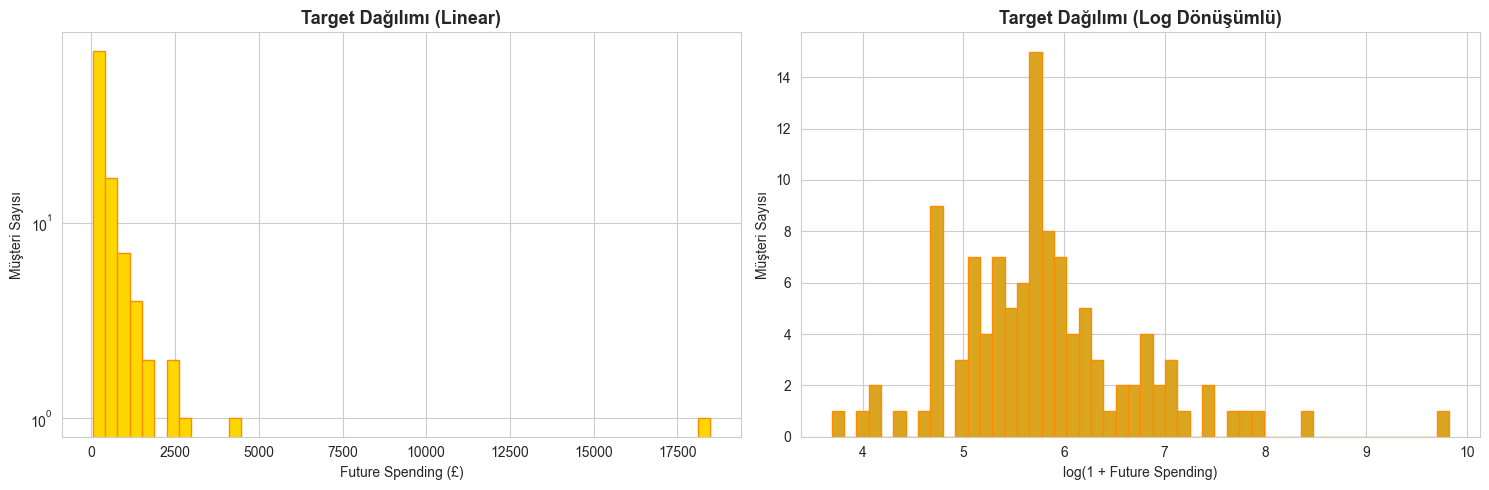


💡 NOT: Target çok çarpık. Faz 7'de log dönüşümü uygulanabilir.


In [17]:
df_target = df_target_period.groupBy("kullanici_ID").agg(
    _sum("total_price").alias("future_spending")
)

print(f"📊 Target dönemde alışveriş yapan müşteri: {df_target.count():,}")
df_target.describe().show()

# Görsel: target dağılımı
df_target_pd = df_target.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Normal histogram
axes[0].hist(df_target_pd['future_spending'], bins=50, color='gold', edgecolor='darkorange')
axes[0].set_xlabel('Future Spending (£)')
axes[0].set_ylabel('Müşteri Sayısı')
axes[0].set_title('Target Dağılımı (Linear)', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')

# Log dönüşümlü
log_target = np.log1p(df_target_pd['future_spending'])
axes[1].hist(log_target, bins=50, color='goldenrod', edgecolor='darkorange')
axes[1].set_xlabel('log(1 + Future Spending)')
axes[1].set_ylabel('Müşteri Sayısı')
axes[1].set_title('Target Dağılımı (Log Dönüşümlü)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/images/06_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n💡 NOT: Target çok çarpık. Faz 7'de log dönüşümü uygulanabilir.")

## 5. Tüm Feature'ları Birleştir → Gold Tablosu

Şimdi tüm feature DataFrame'lerini `kullanici_ID` üzerinden **JOIN** edip tek bir tablo yapacağız.

**Filtreleme:** Sadece **feature döneminde** ve **target döneminde** her ikisinde işlem yapmış müşterileri tutacağız. Bu sayede modelimiz "geçmişten geleceği tahmin" prensibine sadık kalır.

In [18]:
# RFM tablosu en temel feature seti, ondan başlayalım
df_gold = df_rfm \
    .join(df_basket, "kullanici_ID", "left") \
    .join(df_purchase_span, "kullanici_ID", "left") \
    .join(df_unique_products, "kullanici_ID", "left") \
    .join(df_canc_count, "kullanici_ID", "left") \
    .join(df_active_months, "kullanici_ID", "left") \
    .join(df_most_hour, "kullanici_ID", "left") \
    .join(df_customer_country, "kullanici_ID", "left") \
    .join(df_target, "kullanici_ID", "inner")  # SADECE target'ı olan müşteriler

# Cancellation_count null olanları 0 yap (iptal yapmamış demek)
df_gold = df_gold.fillna({"cancellation_count": 0})

print(f"📊 Gold tablo: {df_gold.count():,} müşteri × {len(df_gold.columns)} sütun")
print(f"\n📋 Sütunlar:")
for c in df_gold.columns:
    print(f"   - {c}")

📊 Gold tablo: 11 müşteri × 12 sütun

📋 Sütunlar:
   - kullanici_ID
   - recency_days
   - frequency
   - monetary
   - avg_basket_value
   - avg_days_between_purchases
   - unique_products
   - cancellation_count
   - active_months
   - most_active_hour
   - country
   - future_spending


In [19]:
df_gold.show(10)

print("\n📊 Feature istatistikleri:")
df_gold.describe().show()

+------------+------------+---------+------------------+------------------+--------------------------+---------------+------------------+-------------+----------------+--------------+------------------+
|kullanici_ID|recency_days|frequency|          monetary|  avg_basket_value|avg_days_between_purchases|unique_products|cancellation_count|active_months|most_active_hour|       country|   future_spending|
+------------+------------+---------+------------------+------------------+--------------------------+---------------+------------------+-------------+----------------+--------------+------------------+
|       12921|           2|        1|             261.0|             261.0|                       0.0|              8|                 1|            1|              13|United Kingdom| 993.0000000000002|
|       15794|           1|        1|             675.0|             675.0|                       0.0|             14|                 0|            1|              15|United Kingdom|     

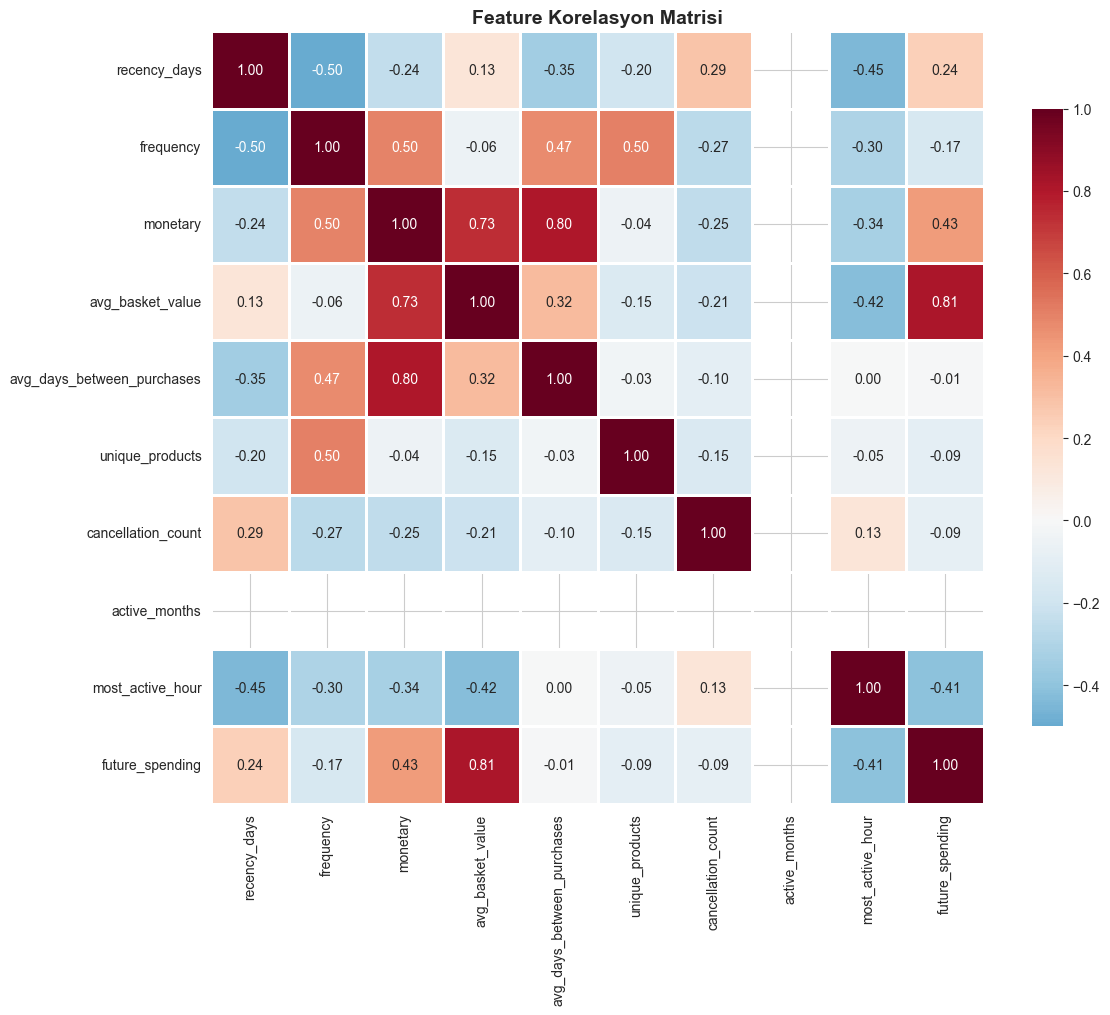


🎯 Target (future_spending) ile korelasyonlar:
future_spending               1.000000
avg_basket_value              0.813508
monetary                      0.425259
recency_days                  0.243610
avg_days_between_purchases   -0.010435
cancellation_count           -0.088819
unique_products              -0.091336
frequency                    -0.170670
most_active_hour             -0.410142
active_months                      NaN
Name: future_spending, dtype: float64


In [20]:
df_gold_pd = df_gold.toPandas()

# Sadece sayısal feature'lar
numeric_cols = ['recency_days', 'frequency', 'monetary', 'avg_basket_value',
                'avg_days_between_purchases', 'unique_products', 'cancellation_count',
                'active_months', 'most_active_hour', 'future_spending']

corr_matrix = df_gold_pd[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/images/06_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Target ile korelasyon
print("\n🎯 Target (future_spending) ile korelasyonlar:")
target_corr = corr_matrix['future_spending'].sort_values(ascending=False)
print(target_corr)

In [21]:
GOLD_PATH = os.path.abspath("../delta_lake/gold/customer_features")

df_gold.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .save(GOLD_PATH)

print(f"✅ Gold tablosu yazıldı: {GOLD_PATH}")

# Doğrula
df_gold_check = spark.read.format("delta").load(GOLD_PATH)
print(f"📊 Doğrulama — Gold: {df_gold_check.count():,} satır × {len(df_gold_check.columns)} sütun")

✅ Gold tablosu yazıldı: /Users/tunakomur/Desktop/big-data-online-retail-pipeline/delta_lake/gold/customer_features
📊 Doğrulama — Gold: 11 satır × 12 sütun


## 6. Özet

✅ **10 feature + 1 target** üretildi  
✅ **Gold tablosu** Delta Lake'e yazıldı: `delta_lake/gold/customer_features`

### Feature Listesi ve İş Mantığı

| Feature | Tip | Neden? |
|---------|-----|--------|
| `recency_days` | Sayısal | Yakın alışveriş yapan müşteri sadık olabilir, gelecekte tekrar alışveriş yapma olasılığı yüksek |
| `frequency` | Sayısal | Sık alışveriş yapan müşteri marka bağımlısıdır |
| `monetary` | Sayısal | Geçmiş harcama gelecek harcamanın en güçlü sinyalidir |
| `avg_basket_value` | Sayısal | Pahalı sepet alışkanlığı olan müşteri yüksek harcayan kategoridedir |
| `avg_days_between_purchases` | Sayısal | Düzenli alışveriş yapan müşteri tahmin edilebilirdir |
| `unique_products` | Sayısal | Ürün çeşitliliği = engaged customer |
| `cancellation_count` | Sayısal | İptal sayısı memnuniyetsizlik sinyali, churn riski |
| `active_months` | Sayısal | Uzun süre aktif olan müşteri gelecekte de aktif olur |
| `most_active_hour` | Sayısal | Davranış paterni — segmentasyon yardımcısı |
| `country` | Kategorik | Coğrafi farklar (UK vs Avrupa) harcama davranışını etkiler |

### Sonraki Faz

Faz 7'de bu Gold tablosundaki müşterileri **5 farklı regresyon modeli** ile eğiteceğiz:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosted Trees (GBT)
5. Generalized Linear Regression (GLR)

MLflow ile tüm deneyleri kaydedeceğiz, en iyi modeli bulacağız.

In [22]:
spark.stop()
print("✅ Spark Session kapatıldı")

✅ Spark Session kapatıldı
